# Workshop 1: Checking Your Foundations: Core Concepts Self-Assessment

**Course:** Geoprocesamiento  
**Program:** Maestría en Geomática  
**Academic Term:** 2026-2  
**Lecturer:** Liliana Castillo Villamor  


---
Throughout this notebook, all demonstrative calculations, cloud-masking routines, and annual anomaly maps are executed using San Luis de Gaceno (my hometown) as the reference study area. Find a geopackage of Colombian Municipalities [**in this Drive Folder**](https://drive.google.com/drive/folders/1LBIwi4xA8khQqD8JimTCjIs2VxbYfr0b?usp=sharing) 

Your Personal Study Area: You are expected to replicate, adapt, and execute this entire workflow for your own chosen region of interest.

Interactive Challenges: As you progress through the notebook, you will encounter dedicated Challenge sections. These require you to modify the code parameters, adapt spatial boundaries, compute custom metrics, and interpret your specific results.

Final Submission & GitHub Repository: You must publish your completed notebook to a dedicated public GitHub repository created specifically for this Geoprocessing course. Maintain a single, structured repository for all course assignments. Upon completion, submit the direct URL of your repository for assessment.

---
## Learning Objectives
By completing this self-assessment and proceeding through the workshop, you will ensure you can:
1. Evaluate Your Remote Sensing Readiness prior to executing automated workflows.
2. Evaluate your ability to distinguish between vector manipulation (`GeoPandas`) and raster array processing (`Rasterio`), identifying when to use each library within a spatial workflow.
3. Benchmark your knowledge of maps algebra, temporal compositing, and pixel-level quality control (cloud masking).
4. Recognise specific technical areas requiring theoretical revision before completing the practical coding challenges in this course.

## 0. Library Imports
Importing the required libraries 
> 🎯**Your Turn 1:** Add comments to explain what each library does.


In [1]:
#extiende la herramienta de pandas para trabajar con datos Geoespaciales vectoriales.
import geopandas as gpd
#libreria principal para crear y usar datos tipo ráster
import rasterio
#submodulo de rasterio para el recorte de rasteres mediante datos vectoriales (poligonos)
import rasterio.mask
#submodulo de rasterio para reproyectar y remuestrear datos tipo ráster
import rasterio.warp
#submodulo de rasterio para usar herramientas de muestreo
from rasterio.enums import Resampling
#API de GEE que permite la consulta, procesamiento y descarga de datos del servidor
import ee
#libreria para el cálculo numérico de python
import numpy as np
#libreria para visualizar graficos
import matplotlib.pyplot as plt
#herramienta para el manejo de rutas de archivos
from pathlib import Path


Eestablish an authenticated session with the Google Earth Engine (GEE) Python API. 

The standard initialization call `ee.Initialize()` verifies your GEE credentials. Wrapping this step inside a `try-except` block ensures that any authentication errors or connection failures are caught gracefully rather than crashing your notebook execution.

In [3]:
ee.Authenticate()

True

In [4]:
# Initialise Google Earth Engine API
try:
    ee.Initialize()
    print("Google Earth Engine initialised successfully.")
except Exception as e:
    print(f"Error initialising GEE: {e}")

C:\Users\Leo\miniconda3\envs\Geoprocesamiento\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(


Google Earth Engine initialised successfully.


## 1: Vector Alignment & Preprocessing

1.  Setting up a dynamic path using Python’s `pathlib.Path` module to point towards your spatial datasets.
2.  Inspecting the original spatial reference of the dataset and reprojecting it to EPSG:9377 (Magna-Sirgas / Origen Nacional)

In [5]:
root_folder=Path(r"C:\Users\Leo\Documents\GEOPROCESAMIENTO")
# Load Colombian municipalities
gdf = gpd.read_file(root_folder /"municipios_colombia.gpkg")

# Display initial spatial reference system
print(f"Initial CRS: {gdf.crs}")

# Reproject to EPSG:9377
gdf_unico = gdf.to_crs(epsg=9377)
#Check the attributes table of our geopandas dataframe
gdf_unico.head()

Initial CRS: EPSG:3116


,DPTO_CCDGO,MPIO_CCDGO,MPIO_CNMBR,MPIO_CDPMP,VERSION,AREA,LATITUD,LONGITUD,STCTNENCUE,STP3_1_SI,...,STP51_PRIM,STP51_SECU,STP51_SUPE,STP51_POST,STP51_13_E,STP51_99_E,Shape_Leng,Shape_Area,Codigo_Mun,geometry
0,18,001,FLORENCIA,18001,2018,2.547638e+09,1.749139,-75.558239,71877.0,32.0,...,48848.0,59610.0,21898.0,4592.0,5892.0,3799.0,2.942508,0.206928,18001,"MULTIPOLYGON (((4730856.146 1800689.038, 47308..."
1,18,029,ALBANIA,18029,2018,4.141221e+08,1.227865,-75.882327,2825.0,24.0,...,1940.0,1712.0,231.0,41.0,215.0,46.0,1.112829,0.033618,18029,"MULTIPOLYGON (((4677933.827 1709133.846, 46779..."
2,18,094,BELÉN DE LOS ANDAQUÍES,18094,2018,1.191619e+09,1.500923,-75.875645,4243.0,54.0,...,3541.0,3340.0,490.0,119.0,720.0,123.0,2.234657,0.096745,18094,"MULTIPOLYGON (((4690015.614 1751610.86, 469000..."
3,18,247,EL DONCELLO,18247,2018,1.106076e+09,1.791386,-75.193944,8809.0,0.0,...,7571.0,6287.0,1029.0,228.0,1095.0,171.0,3.154370,0.089867,18247,"MULTIPOLYGON (((4737450.122 1814755.048, 47374..."
4,18,256,EL PAUJÍL,18256,2018,1.234734e+09,1.617746,-75.234043,5795.0,0.0,...,6072.0,4066.0,639.0,108.0,916.0,99.0,3.529316,0.100309,18256,"MULTIPOLYGON (((4736905.653 1802381.382, 47376..."


> 🎯**Your Turn 2:** Create a new column in your GeoDataFrame named `area_km2` to calculate the surface area of each municipality in square kilometres ($\text{km}^2$). 


In [6]:
# Calcular área en km² en este caso lo importante es tener en cuenta que las coordenadas planas se calculan en metros, por lo que hay que pasar la unidad a km
gdf_unico["area_km2"] = gdf_unico.geometry.area / 1_000_000

# Verificar. en este caso es importante reconocer el nombre de la columna de los municipios
print(gdf_unico[["MPIO_CNMBR", "area_km2"]].head())

               MPIO_CNMBR     area_km2
0               FLORENCIA  2546.958298
1                 ALBANIA   414.100691
2  BELÉN DE LOS ANDAQUÍES  1191.551389
3             EL DONCELLO  1105.514836
4               EL PAUJÍL  1234.140645


❓ Reflection Check 1: What is a GeoDataFrame, and how does it differ from a standard Pandas DataFrame?
Geodataframe es una estructura de datos tabulares (tabla) sin coordenadas. por el contrario Geodataframe que trabaja con geopandas posee entre sus columnas aquella que corresponde a la geometría que almacena de manera geográfica y espacial la informacion de cada fila asociada a un sistema de coodenadas.

> 🎯**Your Turn 3:** Filter the national vector layer to extract your chosen municipality of interest. Store your selection in a new spatial variable (e.g., gdf_muni).

In [7]:
# TODO: Complete the code to filter a specific polygon and apply a spatial buffer.

# 1. Filter the GeoDataFrame for the borough 'Camden'
# Filter the GeoDataFrame for the municipality of SAN LUIS DE GACENO
gdf_muni = gdf_unico[gdf_unico["MPIO_CNMBR"] == "EL PAUJÍL"].copy()

> 🎯**Your Turn 4:** Complete the missing parameters (___) in the code block below to apply a 500-metre buffer around your selected municipality's boundary and assign it as the active spatial geometry.

In [8]:

# 2. Apply a 500-metre buffer to the selected geometry
# HINT: Call the .buffer() method on the geometry column
buffered_shape = gdf_muni.geometry.buffer(500)

# 3. Create a new GeoDataFrame containing the buffered result
gdf_buffered = gdf_muni.copy()
gdf_buffered.set_geometry(buffered_shape, inplace=True)

##set_geometry() le dice al GeoDataFrame cuál columna debe usar como su geometría activa, es decir el buffer que se acaba de crear
# Output geometry confirmation
print(f"Buffered Geometry Type: {gdf_buffered.geometry.type.iloc[0]}")

Buffered Geometry Type: Polygon


<Axes: >

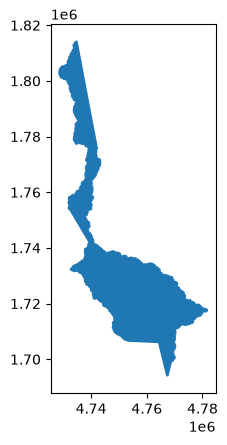

In [13]:
gdf_buffered.plot()

## 2. Earth Engine Extraction & Local Raster Resampling
Exctract Sentinel-2 surface reflectance imagery via GEE, derive the Normalised Difference Vegetation Index ($NDVI$), and resample the grid cell resolution from 10 metres to Landsat imagery using bilinear interpolation.

### Cloud Masking using Sentinel-2 Scene Classification (SCL)
Define a custom Python function (mask_s2_clouds_scl) designed to process Sentinel-2 Level-2A surface reflectance data in Earth Engine. Itinspects the Scene Classification Layer (SCL) band to identify problematic observations. It isolates pixel values representing cloud shadows (class 3), medium-probability clouds (class 8), high-probability clouds (class 9), and cirrus clouds (class 10), combining them into a single binary mask. By applying .updateMask(), all identified cloudy and shadow pixels are masked out (set to transparent/invalid), ensuring that subsequent temporal compositing routines rely strictly on clear surface reflectances.

In [15]:
def mask_s2_clouds_scl(image):
    """Masks clouds, cloud shadows, and cirrus using the SCL band."""
    scl = image.select('SCL')
    
    # Identify unwanted pixel classes
    cloud_shadows = scl.eq(3)
    clouds_medium = scl.eq(8)
    clouds_high = scl.eq(9)
    cirrus = scl.eq(10)
    
    # Combine all mask conditions (1 = invalid pixel)
    mask = cloud_shadows.Or(clouds_medium).Or(clouds_high).Or(cirrus).Not()
    
    # Update image mask and retain properties
    return image.updateMask(mask)

## 3. Extracting, Masking, and Computing NDVI over the Area of Interest

This section converts our local vector boundary into a native Earth Engine geometry (`ee.Geometry`) to query server-side satellite collections. 

The workflow performs four main operations:
1. Reprojects the local bounding box and geometry.
2. Queries the `COPERNICUS/S2_SR_HARMONIZED` collection over the specified date range and applies a preliminary metadata cloud filter (`CLOUDY_PIXEL_PERCENTAGE < 30`).
3. Maps the custom `mask_s2_clouds_scl` function across every image in the collection to remove remaining clouds and shadows.
4. Calculates a temporal median composite, computes the Normalized Difference Vegetation Index (NDVI) using Near-Infrared ($\text{B8}$) and Red ($\text{B4}$) bands:

$$\text{NDVI} = \frac{\text{B8} - \text{B4}}{\text{B8} + \text{B4}}$$

Finally, the resulting index is clipped directly to the exact municipal spatial boundary (`ee_muni_geom`).



In [16]:
# Convert vector bounding box to EPSG:4326 
bbox = gdf_muni.to_crs(epsg=4326).total_bounds
ee_bounds = ee.Geometry.BBox(bbox[0], bbox[1], bbox[2], bbox[3])


geojson_geom = gdf_muni.to_crs(epsg=4326).geometry.iloc[0].__geo_interface__
ee_muni_geom = ee.Geometry(geojson_geom)

# Filter Sentinel-2 collection
s2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(ee_bounds)
    .filterDate("2023-01-01", "2023-12-31") 
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(mask_s2_clouds_scl)
)

# Compute median mosaic, calculate NDVI, and CLIP to exact municipal boundary
median_image = s2_collection.median()
ndvi_image = median_image.normalizedDifference(["B8", "B4"]).rename("NDVI").clip(ee_muni_geom)

print("Sentinel-2 NDVI layer clipped to municipality boundary successfully.")

Sentinel-2 NDVI layer clipped to municipality boundary successfully.


> 🎯 **Your Turn 5**: Why is it necessary to reproject our local vector boundary to EPSG:4326 before querying Earth Engine, even though we previously converted our layer to EPSG:9377 for area calculations?
> #esto es porque el sistema de coordenadas util para hacer cualquier consulta en GEE es el 4326, un sistema universal dintinto al sistema nacional especifico para colombia (SPSG 9377). Por lo tanto, EPSG:4326 lo necesitamos para comunicarnos con GEE

> 🎯 **Your Turn 6:** How can you inspect all available band names within a single Sentinel-2 image or collection using Earth Engine? Write the command required to print this list to the console.

In [10]:
#tomar una imagen que se esté utilizando 
image = s2_collection.first()
#mostrar las bandas de dicha imagen
print(image.bandNames().getInfo())

['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


C:\Users\Leo\miniconda3\envs\Geoprocesamiento\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(


#### 3.1 Interactive Spatial Visualisation using Folium

This section renders our server-side Earth Engine NDVI composite on a client-side interactive map using `folium`.

The rendering process consists of four main steps:
1. Setting minimum (`0.0`) and maximum (`0.8`) spectral thresholds to highlight vegetation density gradients.
2. Retrieving web map tile URLs from Google Earth Engine using `.getMapId()`.
3. Extracting the exact geometric centroid of chosen municipality  to automatically position the map viewport.
4. Adding the GEE raster stream and layer toggles directly into the interactive canvas.


In [17]:
import folium
# Set visualization parameters for the NDVI layer (-1.0 to 1.0 scale)
ndvi_vis = {
    'min': 0.0,
    'max': 0.8,
    'palette': ['blue', 'white', 'green']  # Represents water/bare soil through to dense vegetation
}

# Fetch the map URL dictionary directly from Google Earth Engine servers
map_id_dict = ndvi_image.getMapId(ndvi_vis)

# Calculate the precise centroid in the projected CRS (metres) before reprojecting to WGS84 (EPSG:4326)
centroid_point = gdf_muni.geometry.centroid.to_crs(epsg=4326).iloc[0]
centroid = [centroid_point.y, centroid_point.x]

# Initialise interactive Folium map centred on the municipal boundary
m = folium.Map(location=centroid, zoom_start=11)

# Add the GEE Sentinel-2 NDVI raster layer to the map interface
folium.TileLayer(
    tiles=map_id_dict['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    name='Sentinel-2 NDVI',
    overlay=True,
    control=True
).add_to(m)

# Render layer contal visualizar la imagen queda solo la mitad de la imagen dentro derols and display the interactive map
folium.LayerControl().add_to(m)
m

C:\Users\Leo\miniconda3\envs\Geoprocesamiento\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(


> 🎯 **Your Turn 7:** Modify the visualization parameters in the code block above to change the color palette and scale threshold:
> - Adjust the maximum NDVI value (`max`)** to **0.7.
> - Change the color palette so that values transition towards red for high vegetation density.
> 


In [19]:
import folium
# Set visualization parameters for the NDVI layer (-1.0 to 1.0 scale)
#para responder a la pregunta toca modificar esta primera sección:
ndvi_vis = {
    'min': 0.0,
    'max': 0.9,
    'palette': ['blue', 'white', 'red']  # Represents water/bare soil through to dense vegetation
}

# Fetch the map URL dictionary directly from Google Earth Engine servers
map_id_dict = ndvi_image.getMapId(ndvi_vis)

# Calculate the precise centroid in the projected CRS (metres) before reprojecting to WGS84 (EPSG:4326)
centroid_point = gdf_muni.geometry.centroid.to_crs(epsg=4326).iloc[0]
centroid = [centroid_point.y, centroid_point.x]

# Initialise interactive Folium map centred on the municipal boundary
m = folium.Map(location=centroid, zoom_start=11)

# Add the GEE Sentinel-2 NDVI raster layer to the map interface
folium.TileLayer(
    tiles=map_id_dict['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    name='Sentinel-2 NDVI',
    overlay=True,
    control=True
).add_to(m)

# Render layer contal visualizar la imagen queda solo la mitad de la imagen dentro derols and display the interactive map
folium.LayerControl().add_to(m)
m

## 4. Cross-Sensor Comparison & Spatial Resampling: Landsat 8 OLI vs Sentinel-2 MSI

Compare vegetation index metrics derived from two distinct satellite constellations over your chosen municipality: **Landsat 8 OLI**  and **Sentinel-2 MSI** 

This multi-sensor workflow involves three core steps:
1. Radiometric scaling of surface reflectance bands and calculation of 30-metre NDVI.
2. Aggregating Sentinel-2 pixels to match the lower spatial resolution grid of Landsat 8 using spatial reduction  and reprojection.
3. Integrating both aligned datasets into an interactive split-panel map  for side-by-side spatial inspection.



In [22]:
# Filter Landsat 8 collection for the same area and timeframe
# Filter Landsat 8 collection (sin aplicar el enmascaramiento de S2)
l8_collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(ee_muni_geom)
    .filterDate("2023-01-01", "2023-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
)

# Scaling function for Landsat 8 Surface Reflectance 
def scale_landsat8(image):
    optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical_bands, None, True)

# Compute median mosaic, scale values, compute NDVI (B5 = NIR, B4 = Red), and clip
l8_scaled = l8_collection.map(scale_landsat8).median()
l8_ndvi_30m = l8_scaled.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI_L8').clip(ee_muni_geom)

print("Landsat 8 OLI NDVI successfully processed.")

Landsat 8 OLI NDVI successfully processed.


> 🎯 **Your Turn 8:** Look closely at the `scale_landsat8` function above. Why is it necessary to apply a scale factor (`0.0000275`) and an offset (`-0.2`) to the Landsat 8 Level-2 Surface Reflectance bands (`SR_B.`) before calculating spectral indices like NDVI?
>
> #esto se debe a que los valores de reflectancia L8 nivel 2 no estan guardados como reflectancia real. la USGS almacena estos datos de manera comprimida para ahorrar almacenamieto. por lo tanto, para descomprimirlo hay que aplicar la formula: Reflectancia real = valor almacenado x factor de escala (0.0000275) + offset (-0.2)


### 4.1. Spatial Resampling and Coordinate Grid Alignment

This subsection handles the spatial alignment between datasets captured at different spatial resolutions.

While Sentinel-2 provides a native resolution of 10 metres per pixel, Landsat 8 operates at a coarser 30-metre resolution. To perform a valid pixel-by-pixel cross-sensor comparison, the 10-metre Sentinel-2 NDVI raster must be aggregated to match the 30-metre target spatial grid of Landsat 8.

1. Retrieves the native projection metadata (`ee.Projection`) from raw single-date collection assets prior to temporal reduction operations.
2. Aggregates higher-resolution (10m) pixels falling within each target lower-resolution (30m) pixel using a spatial mean reducer (`ee.Reducer.mean()`).
3.  Forces the resampled Sentinel-2 layer to adopt the exact Coordinate Reference System and pixel grid alignment of the target Landsat 8 raster .

---

In [23]:
# 1. Extract valid native projections from raw image items (before computing median)
s2_native_proj = s2_collection.first().select("B4").projection()
landsat_proj = l8_collection.first().select("SR_B5").projection()

# 2. Resample Sentinel-2 NDVI to match Landsat 8 grid using native resolution
s2_ndvi_30m = (
    ndvi_image
    .setDefaultProjection(crs=s2_native_proj)  
    .reduceResolution(
        reducer=ee.Reducer.mean(),
        maxPixels=1024
    )
    .reproject(
        crs=landsat_proj  # Align directly to Landsat 8 spatial reference frame
    )
    .clip(ee_muni_geom)
)

print("Sentinel-2 projection reference successfully assigned.")

Sentinel-2 projection reference successfully assigned.


> 🎯 **Your Turn 9:** Examine the spatial resampling chain applied to the Sentinel-2 NDVI layer (`.reduceResolution()` combined with `.reproject()`). 
> 
> Why is `ee.Reducer.mean()` used to aggregate the 10-metre Sentinel-2 pixels into the 30-metre Landsat grid instead of the resampling method like Nearest-Neighbour ?
##Por que está pasando de una resolucion fina a una más gruesa. por lo que se calcula el primedio de los pixeles de sentinel que caen sobre el pixel de landsat (operación de agregación) upscaling.
> #por el contrario Nearest-Neighbour asume solo un pixel e ignora por completo los otros.

### 4.2. Comparative Visualisation using Split-Panel Interactive Maps

Sets up a side-by-side spatial comparison of the resampled Sentinel-2 NDVI * and the native Landsat 8 NDVI  layers over the municipal territory.

1. Converts Earth Engine raster objects into interactive map tiles using uniform visual parameters.
2. Instantiates a interactive map centered on the municipal centroid.
3. Binds both layers into a split-panel view , introducing an interactive slider handle to dynamically evaluate local spectral consistency across both sensors.


In [24]:
import geemap

# Define standard NDVI visualization parameters
ndvi_vis = {
    'min': 0.0,
    'max': 0.8,
    'palette': ['blue', 'white', 'green']
}

# Convert Earth Engine images into TileLayers for geemap
left_layer = geemap.ee_tile_layer(s2_ndvi_30m, ndvi_vis, 'Sentinel-2 NDVI (30m)')
right_layer = geemap.ee_tile_layer(l8_ndvi_30m, ndvi_vis, 'Landsat 8 NDVI (30m)')

# Initialise split-panel map centred on the municipality
Split_Map = geemap.Map(center=centroid, zoom=11)
Split_Map.split_map(left_layer=left_layer, right_layer=right_layer)

# Display interactive split map
Split_Map

C:\Users\Leo\miniconda3\envs\Geoprocesamiento\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(


Map(center=[1.6177609969533753, -75.23402025278985], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## 5. Vector Masking & Spatial Extraction
Evolves from a single-year analysis into a multi-temporal baseline study using the Sentinel-2 Harmonised collection across a 10-year span (2016–2025).

1. Iterates over a sequence of years using  to build a custom  where each image represents a cloud-masked median NDVI composite for that specific year.
2. Enables server-side temporal filtering.
3. Calculates the pixel-wise mean  across the entire multi-year collection to establish the long-term historical average.
4. Derives the relative vegetation anomaly for a target year 2023 by subtracting the multi-year mean from the target year's composite:

$$\text{NDVI Anomaly}_{2023} = \text{NDVI}_{2023} - \text{NDVI}_{\text{Historical Baseline}}$$

> 💡Positive values indicate above-average vegetation vigour (greening), while negative values highlight vegetation stress, deforestation, or drought conditions relative to the long-term mean.

In [25]:
import geemap

# 1. Define range of available years for Sentinel-2 Harmonised (2016 to 2025)
years = ee.List.sequence(2017, 2025)

# 2. Map function to generate an annual composite and compute NDVI per year
def compute_annual_ndvi(year):
    date_start = ee.Date.fromYMD(year, 1, 1)
    date_end = ee.Date.fromYMD(year, 12, 31)
    
    annual_s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(ee_muni_geom)
        .filterDate(date_start, date_end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
        .map(mask_s2_clouds_scl)
        .median()
    )
    
    annual_ndvi = (
        annual_s2
        .normalizedDifference(["B8", "B4"])
        .rename("NDVI")
        .set("year", year)
    )
    
    return annual_ndvi

# Build ImageCollection containing one NDVI image per year
annual_ndvi_collection = ee.ImageCollection(years.map(compute_annual_ndvi))

# 3. Compute the long-term baseline average across all available years
historical_mean_ndvi = annual_ndvi_collection.mean().clip(ee_muni_geom)

# 4. Compute annual anomaly for a target year (e.g., 2023)
target_year = 2023
target_ndvi = (
    annual_ndvi_collection
    .filter(ee.Filter.eq("year", target_year))
    .first()
    .clip(ee_muni_geom)
)

# Difference calculation: Current Year minus Historical Baseline
ndvi_anomaly_2023 = target_ndvi.subtract(historical_mean_ndvi).rename("NDVI_Anomaly")

print(f"Annual NDVI Anomaly successfully computed for year {target_year}.")

Annual NDVI Anomaly successfully computed for year 2023.


> 🎯 **Your Turn 10:** Now that you have computed `ndvi_anomaly_2023`, write the Python code to display this anomaly layer on an interactive `geemap.Map`.
> 
> **Requirements:**
> 1. Define appropriate visualization parameters suited for differences:
>    - Set the range between `-0.3` (negative anomaly / vegetation degradation) and `0.3` (positive anomaly / vegetation growth).
>    - Use a diverging color palette such as `['red', 'white', 'green']` or `['brown', 'yellow', 'darkgreen']`.
> 2. Initialize a `geemap.Map` centered on the municipal centroid (`centroid`) with zoom level `11`.
> 3. Add `ndvi_anomaly_2023` to the map interface and display it.

In [26]:
# Write your script here:
anomaly_vis = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['red', 'white', 'green']
}
Map_anomaly = geemap.Map(center=centroid, zoom=11)
Map_anomaly.add_layer(ndvi_anomaly_2023, anomaly_vis, 'NDVI Anomaly 2023')
Map_anomaly

Map(center=[1.6177609969533753, -75.23402025278985], controls=(WidgetControl(options=['position', 'transparent…

In [27]:
#tamaños de la coleccion de datos utilizados 
for y in range(2016, 2026):
    count = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(ee_muni_geom)
        .filterDate(f"{y}-01-01", f"{y}-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
        .size()
        .getInfo()
    )
    print(y, count)

2016 0
2017 9
2018 6
2019 20
2020 18
2021 24
2022 33
2023 18
2024 32
2025 22


In [ ]:
#como el año 2016 no tiene datos, toca ajustar los datos a partir del 2017

## 5. Interactive Multi-Decadal Anomaly Visualisation 

Renders the complete time series of annual NDVI anomalies (2016–2025) onto a single interactive `geemap` canvas for temporal exploration.

1.  Defines a symmetrical ColorBrewer palette to distinguish vegetation gain from loss.
2. Adds the 10-year historical mean NDVI as an optional reference layer (hidden by default).
3. Loops through every year from 2016 to 2025, computing each year's departure from the historical baseline and adding it as a toggleable map layer (keeping 2023 active by default).
4. Constructs a custom dictionary mapping quantitative anomaly intervals to qualitative health states 
5. Appends an interactive legend box and layer control panel to enable rapid multi-temporal toggling and comparative analysis across years.


In [29]:
import geemap

# 1. Define explicit color palette: Red (Negative/Stress) -> Yellow (Neutral) -> Green (Positive/Healthy)
anomaly_vis = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#ffffbf', '#d9ef8b', '#a6d96a', '#66bd63', '#1a9850']
}

# 2. Initialise interactive map centred on San Luis de Gaceno
Map_Anomalies = geemap.Map(center=centroid, zoom=11)

# 3. Add historical baseline mean layer (10-year reference, off by default)
Map_Anomalies.addLayer(
    historical_mean_ndvi, 
    {'min': 0.0, 'max': 0.8, 'palette': ['blue', 'white', 'green']}, 
    'Baseline: Historical Mean NDVI (2017-2025)',
    False
)

# 4. Iteratively compute and add individual annual anomaly layers (2016-2025)
year_list = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for y in year_list:
    # Extract annual NDVI layer for year 'y'
    annual_ndvi = (
        annual_ndvi_collection
        .filter(ee.Filter.eq("year", y))
         
        .first()
            
        .clip(ee_muni_geom)
    )
    
    # Calculate anomaly: (Year NDVI - Historical Baseline Mean)
    annual_anomaly = annual_ndvi.subtract(historical_mean_ndvi).rename(f"Anomaly_{y}")
    
    # Keep 2023 visible by default for immediate visual assessment
    show_layer = True if y == 2023 else False
    
    # Add annual anomaly layer with toggles
    Map_Anomalies.addLayer(
        annual_anomaly, 
        anomaly_vis, 
        f'NDVI Anomaly {y}', 
        show_layer
    )

# 5. Define discrete legend entries for student interpretation
legend_dict = {
    'Positive Anomaly (> +0.15 NDVI)': '#1a9850',  # Dark green
    'Slightly Positive (+0.05 to +0.15)': '#a6d96a', # Light green
    'Normal Baseline (-0.05 to +0.05)': '#ffffbf',  # Yellow/Neutral
    'Slightly Negative (-0.15 to -0.05)': '#fdae61', # Orange
    'Negative Anomaly (< -0.15 NDVI)': '#d73027'   # Red
}

# Add legend and layer control widgets to the map UI
Map_Anomalies.add_legend(title="NDVI Anomaly Legend", legend_dict=legend_dict)
Map_Anomalies.add_layer_control()

Map_Anomalies

Map(center=[1.6177609969533753, -75.23402025278985], controls=(WidgetControl(options=['position', 'transparent…

### 5.1. Continuous Linear Visualisation of Annual NDVI Time Series

Renders the raw annual NDVI composites across the 10-year period (2016–2025) using a continuous sequential color ramp rather than anomaly differences.

1. Defines a continuous 5-step hex color gradient scaled linearly between `0.0` (bare soil/water) and `0.8` (dense vegetation canopy).
2. Integrates the multi-year baseline average (`historical_mean_ndvi`) as a reference layer for long-term canopy evaluation.
3. Filters `annual_ndvi_collection` year by year, clipping each annual composite to the municipal boundary and adding it to the map interface (setting 2023 visible by default).
4. Binds a horizontal colorbar widget irectly to the map canvas to represent absolute numerical vegetation density rather than discrete categories.
5. Adds layer controls to allow students to visually inspect inter-annual canopy variations across individual years.

---

In [30]:
import geemap

# 1. Define continuous linear visual parameters (pure white to deep forest green)
ndvi_vis_continuous = {
    'min': 0.0,
    'max': 0.8,
    'palette': ['#ffffff', '#e5f5e0', '#a1d99b', '#31a354', '#006d2c']
}

# 2. Initialise interactive map centred on San Luis de Gaceno
Map_Annual_NDVI_Linear = geemap.Map(center=centroid, zoom=11)

# 3. Add historical baseline mean layer as benchmark (off by default)
Map_Annual_NDVI_Linear.addLayer(
    historical_mean_ndvi, 
    ndvi_vis_continuous, 
    'Baseline: Historical Mean NDVI (2017-2025)',
    False
)

# 4. Iteratively add individual annual NDVI layers (2016-2025)
year_list = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for y in year_list:
    # Extract annual NDVI composite for year 'y'
    annual_ndvi = (
        annual_ndvi_collection
        .filter(ee.Filter.eq("year", y))
        .first()
        .clip(ee_muni_geom)
    )
    
    # Keep 2023 active by default; keep remaining years unchecked initially
    show_layer = True if y == 2023 else False
    
    # Add layer to interactive map
    Map_Annual_NDVI_Linear.addLayer(
        annual_ndvi, 
        ndvi_vis_continuous, 
        f'NDVI Year {y}', 
        show_layer
    )

# 5. Add a continuous linear colorbar legend (White to Green)
Map_Annual_NDVI_Linear.add_colorbar(
    vis_params=ndvi_vis_continuous,
    label="NDVI Index Value (Continuous)",
    orientation="horizontal",
    layer_name="NDVI Linear Scale"
)

# Add layer control toggle panel for students
Map_Annual_NDVI_Linear.add_layer_control()

# Display map
Map_Annual_NDVI_Linear

Map(center=[1.6177609969533753, -75.23402025278985], controls=(WidgetControl(options=['position', 'transparent…

### 5.2. Multi-Temporal True-Colour (RGB) Composite Exploration

Build a multi-year collection of natural-colour (True-Colour) imagery over the study area to provide visual ground truth across the 2016–2025 time horizon.
The aim is to have the natural-color image to facilitate the changes analysis over time. 
1. Constructs an image collection where each item is a cloud-masked, surface-reflectance median composite clipped to the municipal geometry (`ee_muni_geom`).
2. Applies standard Sentinel-2 RGB band mapping (`B4` = Red, `B3` = Green, `B2` = Blue) scaled between `0` and `3000` SR units. 
3.  Loops through each annual composite, loading every individual year onto the interactive map interface. Keeps 2023 active by default.


> 🎯 **Your Turn 11:** Review the custom `compute_annual_rgb` function defined above. Explain in your own words as a comment what each step inside the pipeline achieves:
> 
> 1. How does Earth Engine handle date boundaries when filtering image collections?
> 2. What is the functional difference between taking the median composite of an image collection versus taking a single image scene, and why is clipping performed at the very end of the pipeline?


In [21]:
def compute_annual_rgb(year):
    date_start = ee.Date.fromYMD(year, 1, 1)   # Define el inicio del año (1 de enero) 
    date_end = ee.Date.fromYMD(year, 12, 31)   # Define el final del año (31 de diciembre)

    annual_s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")   # Accede a la colección de Sentinel-2
        .filterBounds(ee_muni_geom)                         # Conserva solo imágenes que intersectan el municipio
        .filterDate(date_start, date_end)                   # Conserva solo imágenes tomadas dentro de ese año
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))# Descarta imágenes con más de 30% de nubosidad
        .map(mask_s2_clouds_scl)                            # Aplica máscara de nubes píxel a píxel usando
        .median()                                           # Calcula el valor mediano por píxel entre todas las escenas del año
        .clip(ee_muni_geom)                                 # Recorta el resultado final exactamente al límite del municipio
    )
    
    return annual_s2.set("year", year)   # Etiqueta la imagen resultante con la propiedad "year" para poder filtrarla después

# Build collection containing one S2 composite per year (2016-2025)
years = ee.List.sequence(2017, 2025)
annual_rgb_collection = ee.ImageCollection(years.map(compute_annual_rgb))

# 2. Define RGB visualization parameters (B4 = Red, B3 = Green, B2 = Blue)
rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.4  # Slight gamma adjustment for optical clarity
}

# 3. Initialise interactive map centred on San Luis de Gaceno
Map_Annual_RGB = geemap.Map(center=centroid, zoom=11)

# 4. Iteratively add individual annual RGB layers (2016-2025)
year_list = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for y in year_list:
    # Filter the collection for year 'y'
    annual_rgb = (
        annual_rgb_collection
        .filter(ee.Filter.eq("year", y))
        .first()
    )
    
    # Keep 2023 visible by default for baseline verification
    show_layer = True if y == 2023 else False
    
    # Add annual RGB layer with individual checkboxes
    Map_Annual_RGB.addLayer(
        annual_rgb, 
        rgb_vis, 
        f'Sentinel-2 RGB {y}', 
        show_layer
    )

# Add layer control toggle panel for student verification
Map_Annual_RGB.add_layer_control()

# Display interactive map
Map_Annual_RGB


Map(center=[1.6177609969533753, -75.23402025278985], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
#Google Earth Engine es inclusivo en el inicio y exclusivo en el final con base a las fechas estipuladas. 
#como una sola escena representa un unico momento, que puede contener vacios de información o nubes que ocultan los datos de la superficie de la tierra, el Composite mediante la mediacombina las escenas dentro de un periodo de tiempo tomando la media de los valores del pixel por año. asi el resultado funciona como un filtrado donde los valores atipicos qudan por fuera de la media. 
#para evitar problemas y errores en el procesaiento es mejor recordar el resultado de la escena(s) al final del proceso

## 6. Final Assessment & Independent Exercise: Multi-Sensor Alternative Spectral Index & Time-Series Export


🎯 **Your Turn 12 (Final Synthesis Challenge):**

> Create a new Jupyter Notebook in your GitHub repository and replicate what you  consider is necessary to reach waht is required as follows:
>
>  1. Choose one index distinct from NDVI (e.g., **EVI**, **SAVI**, or **NDWI**) for canopy, soil, or moisture evaluation.
> 2.Generate annual median composites for both **Sentinel-2** and **Landsat 8** over your area, applying sensor-specific cloud masking (SCL / QA_PIXEL) and Landsat 8 Surface Reflectance scaling factors.
> 3. **Construct Multi-Temporal Stacks:** Combine the 10 annual index layers (2016 to 2025) into a single 10-band `ee.Image` stack for Sentinel-2 and a corresponding 10-band stack for Landsat 8 (renaming bands sequentially as `Index_2016`, `Index_2017`, ..., `Index_2025`).
> 4. **GeoTIFF Export:** Export both 10-band image stacks to Google Drive as projected GeoTIFF rasters using the official local CRS for Colombia (**EPSG:9377**).

> 5. Commit and push your final `.ipynb` file to your public GitHub repository.
> 6. Ensure your notebook contains executed output cells, structured Markdown headers, and code comments explaining your custom study area selection.
> 7. Copy the direct link to your Jupyter Notebook on GitHub and submit it using the following link:
>
> 📋 [**Submit Your Final Notebook Link Here**](https://forms.gle/73ypriddjvWtarV8A)

---
